In [1]:
# Importing Packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import LeaveOneOut, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
import warnings
warnings.filterwarnings("ignore")

In [3]:
dataset = pd.read_csv("/content/input_prod_sar.csv")
print(f"Dataset shape: {dataset.shape}")
dataset

Dataset shape: (11, 20)


,Year,Precipitation,maxtemp,mintemp,avgtemp,specifichumidity,relativehumidity,surfacepressure,dewpoints,minwindspeed,maxwindspeed,cloudcoverage,Nitrogen,Phosphorus,Pottasium,pH,VH_mean,VV_mean,RVI,Production
0,2015,496.85,33.33,19.83,13.50,0.011725,51.94,94.15,14.38,2.37,5.85,0.55,-1,1,2,2,-16.966225,-10.233417,0.649242,1410443.725
1,2016,801.98,32.84,19.31,13.53,0.011382,53.13,94.10,13.68,2.48,5.91,0.54,0,2,2,2,-16.965433,-10.101258,0.663100,1815274.444
2,2017,827.51,32.74,19.21,13.53,0.011535,53.82,94.08,13.67,2.33,5.78,0.55,-1,1,1,2,-18.405242,-10.914717,0.672425,1444922.863
3,2018,353.50,33.03,19.62,13.41,0.011057,50.04,94.09,13.36,2.29,5.93,0.56,-2,-1,0,3,-18.574225,-10.863525,0.652692,982068.374
4,2019,1057.54,32.80,19.20,13.60,0.011498,53.60,94.10,13.60,2.30,5.80,0.60,-1,1,2,2,-18.144833,-10.435917,0.631733,1444922.863
5,2020,745.34,32.76,19.30,13.53,0.011365,50.55,94.09,13.48,2.46,5.95,0.56,-1,1,2,2,-17.909733,-10.163892,0.638483,1394000.000
6,2021,780.50,32.50,19.10,13.45,0.011400,51.20,94.07,13.55,2.50,5.90,0.55,0,1,1,2,-17.776767,-10.090050,0.646925,1462500.000
7,2022,810.30,32.30,18.90,13.35,0.011500,52.00,94.05,13.65,2.55,5.85,0.54,0,2,2,2,-17.204350,-9.702508,0.666175,1515000.000
8,2023,840.80,32.10,18.70,13.25,0.011600,53.00,94.03,13.75,2.60,5.80,0.53,-1,1,2,2,-17.936492,-10.155967,0.648992,1554500.000
9,2024,870.50,31.90,18.50,13.15,0.011700,54.00,94.01,13.85,2.65,5.75,0.52,0,2,2,2,-17.531683,-9.997567,0.657925,1594000.000


In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              11 non-null     int64  
 1   Precipitation     11 non-null     float64
 2   maxtemp           11 non-null     float64
 3   mintemp           11 non-null     float64
 4   avgtemp           11 non-null     float64
 5   specifichumidity  11 non-null     float64
 6   relativehumidity  11 non-null     float64
 7   surfacepressure   11 non-null     float64
 8   dewpoints         11 non-null     float64
 9   minwindspeed      11 non-null     float64
 10  maxwindspeed      11 non-null     float64
 11  cloudcoverage     11 non-null     float64
 12  Nitrogen          11 non-null     int64  
 13  Phosphorus        11 non-null     int64  
 14  Pottasium         11 non-null     int64  
 15  pH                11 non-null     int64  
 16  VH_mean           11 non-null     float64
 17 

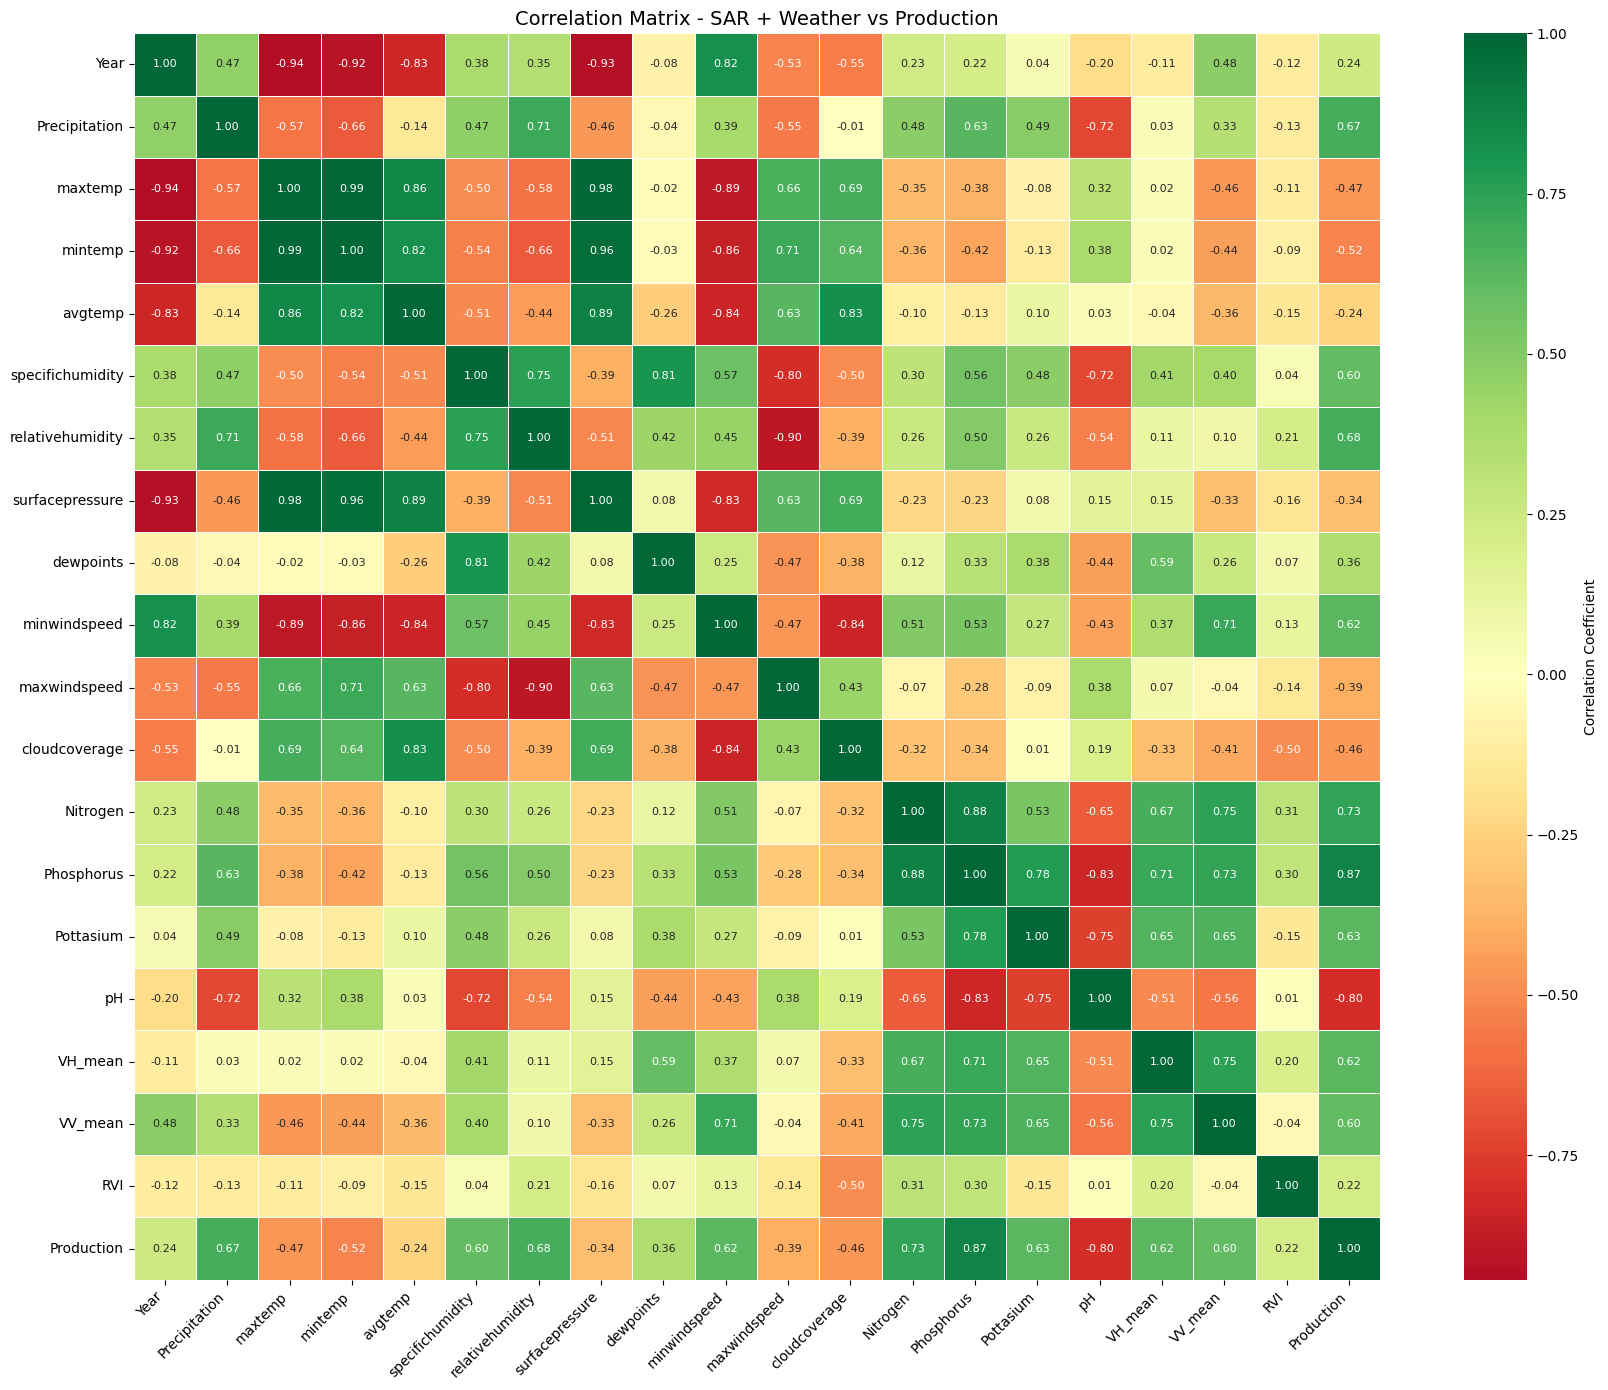

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 14))

# Keep only numeric columns (optional but safe)
correlation = dataset.select_dtypes(include=['number']).corr()

sns.heatmap(correlation,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            square=True,
            linewidths=0.5,
            annot_kws={"size": 8},
            cbar_kws={'label': 'Correlation Coefficient'})

plt.title('Correlation Matrix - SAR + Weather vs Production', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [7]:
dataset = dataset.sort_values("Year").reset_index(drop=True)

dataset["Production_lag1"] = dataset["Production"].shift(1).bfill()
dataset["Precip_rolling3"] = dataset["Precipitation"].rolling(window=3, min_periods=1).mean()
dataset["Temp_rolling3"]   = dataset["avgtemp"].rolling(window=3, min_periods=1).mean()

print("Lag and rolling features:")
print(dataset[["Year","Production","Production_lag1","Precipitation","Precip_rolling3","avgtemp","Temp_rolling3"]].to_string(index=False))

Lag and rolling features:
 Year  Production  Production_lag1  Precipitation  Precip_rolling3  avgtemp  Temp_rolling3
 2015 1410443.725      1410443.725         496.85       496.850000    13.50      13.500000
 2016 1815274.444      1410443.725         801.98       649.415000    13.53      13.515000
 2017 1444922.863      1815274.444         827.51       708.780000    13.53      13.520000
 2018  982068.374      1444922.863         353.50       660.996667    13.41      13.490000
 2019 1444922.863       982068.374        1057.54       746.183333    13.60      13.513333
 2020 1394000.000      1444922.863         745.34       718.793333    13.53      13.513333
 2021 1462500.000      1394000.000         780.50       861.126667    13.45      13.526667
 2022 1515000.000      1462500.000         810.30       778.713333    13.35      13.443333
 2023 1554500.000      1515000.000         840.80       810.533333    13.25      13.350000
 2024 1594000.000      1554500.000         870.50       840.5333

In [8]:
# 21 features: 18 base + Production_lag1 + Precip_rolling3 + Temp_rolling3
feature_cols = ['Precipitation', 'maxtemp', 'mintemp', 'avgtemp',
                'specifichumidity', 'relativehumidity', 'surfacepressure',
                'dewpoints', 'minwindspeed', 'maxwindspeed', 'cloudcoverage',
                'Nitrogen', 'Phosphorus', 'Pottasium', 'pH',
                'VH_mean', 'VV_mean', 'RVI',
                'Production_lag1', 'Precip_rolling3', 'Temp_rolling3']

X = dataset[feature_cols]
y = dataset['Production']

print(f"Features: {X.shape[1]}  |  Samples: {X.shape[0]}")

Features: 21  |  Samples: 11


In [9]:
from sklearn.model_selection import LeaveOneOut
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Define models
models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Linear Regression': LinearRegression(),
    'SVR': SVR(kernel='rbf', C=100, gamma='scale'),
    'KNN': KNeighborsRegressor(n_neighbors=3),
    'HistGradientBoosting': HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_depth=3,
        max_iter=100,
        random_state=42
    )
}

all_results = {}
all_predictions = {}

# Loop through models
for name, model in models.items():
    loo = LeaveOneOut()
    preds, actuals = [], []

    # Models that need scaling
    needs_scaling = name in ['SVR', 'KNN']

    for train_idx, test_idx in loo.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        if needs_scaling:
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

        model.fit(X_train, y_train)
        pred = model.predict(X_test)

        preds.append(pred[0])
        actuals.append(y_test.values[0])

    # Metrics
    mae = mean_absolute_error(actuals, preds)
    rmse = np.sqrt(mean_squared_error(actuals, preds))
    r2 = r2_score(actuals, preds)

    # Store results
    all_results[name] = {
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    }

    all_predictions[name] = (actuals, preds)

    # Print results
    print(f"{name:25s} | MAE: {mae:12.2f} | RMSE: {rmse:12.2f} | R2: {r2:8.4f}")

Random Forest             | MAE:    116542.71 | RMSE:    196617.28 | R2:  -0.0147
Linear Regression         | MAE:    363201.53 | RMSE:    483514.70 | R2:  -5.1365
SVR                       | MAE:    148098.45 | RMSE:    207344.65 | R2:  -0.1285
KNN                       | MAE:    161249.77 | RMSE:    205246.45 | R2:  -0.1057
HistGradientBoosting      | MAE:    145242.86 | RMSE:    214704.81 | R2:  -0.2100


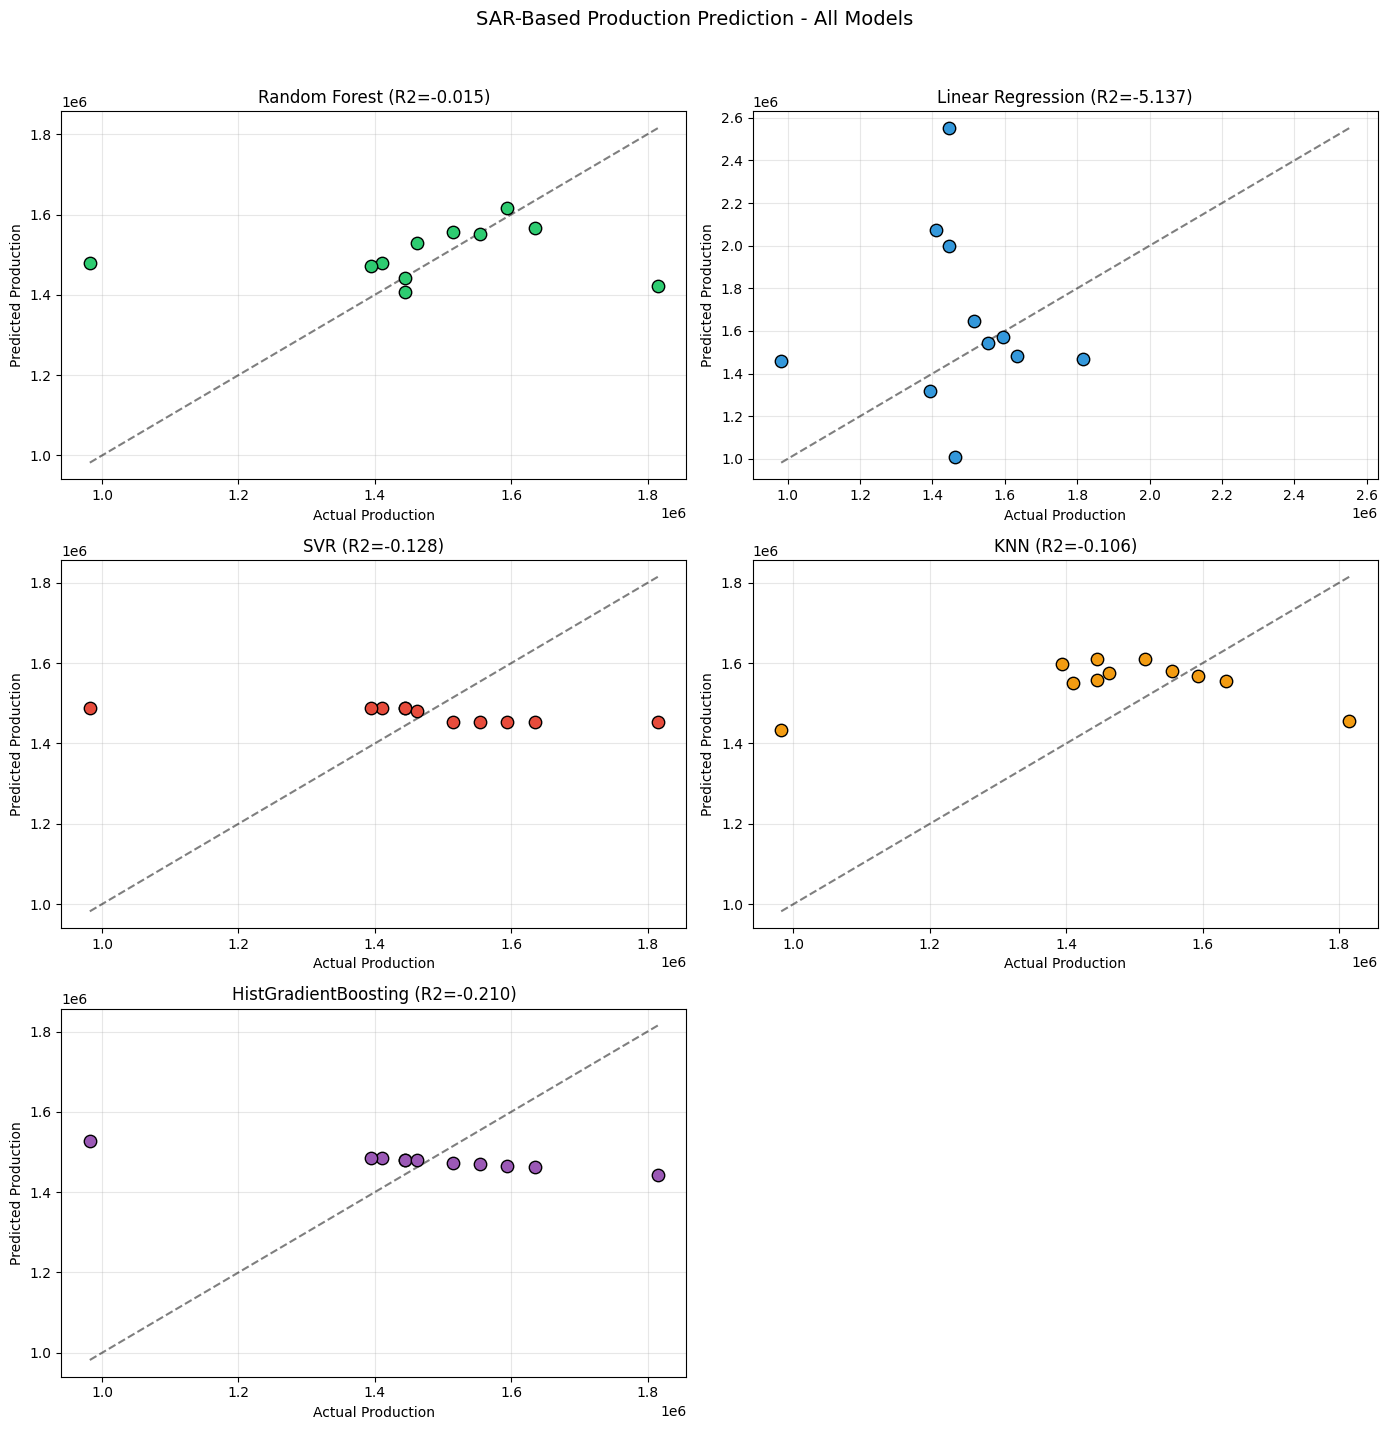

In [10]:
import matplotlib.pyplot as plt

# Visualization: Actual vs Predicted
# Adjusted subplot grid to 3 rows, 2 columns to accommodate 5 models
fig, axes = plt.subplots(3, 2, figsize=(14, 15)) # Increased figsize for better readability
axes = axes.flatten() # Flatten the 2x2 array of axes for easier iteration
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6'] # Added one more color

for idx, (name, (actual, predicted)) in enumerate(all_predictions.items()):
    # Use the flattened axes array
    ax = axes[idx]
    ax.scatter(actual, predicted, c=colors[idx], edgecolors='black', s=80, zorder=5)
    min_val = min(min(actual), min(predicted))
    max_val = max(max(actual), max(predicted))
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5)
    ax.set_xlabel('Actual Production')
    ax.set_ylabel('Predicted Production')
    ax.set_title(f"{name} (R2={all_results[name]['R2']:.3f})")
    ax.grid(True, alpha=0.3)

# Hide any unused subplots if the number of models is less than total subplots
for i in range(len(all_predictions), len(axes)):
    fig.delaxes(axes[i])

plt.suptitle('SAR-Based Production Prediction - All Models', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Adjust layout to prevent suptitle overlap
plt.show()

## Cross-Validation Comparison: LOO-CV vs TimeSeriesSplit

LOO-CV maximises training data but can use future data to predict the past.
TimeSeriesSplit always trains on past, predicts future — more realistic for deployment.
The production `train_model.py` uses TimeSeriesSplit.

In [12]:
tscv = TimeSeriesSplit(n_splits=3)

print("TimeSeriesSplit fold structure:")
for i, (tr, te) in enumerate(tscv.split(X)):
    print(f"  Fold {i+1}: train={dataset.iloc[tr]['Year'].tolist()} | test={dataset.iloc[te]['Year'].tolist()}")

tscv_results = {}
model_factories = [
    ("Random Forest",        lambda: RandomForestRegressor(n_estimators=100, random_state=42), False),
    ("Linear Regression",    lambda: LinearRegression(), False),
    ("SVR",                  lambda: SVR(kernel="rbf", C=100, gamma="scale"), True),
    ("KNN",                  lambda: KNeighborsRegressor(n_neighbors=3), True),
    ("HistGradientBoosting", lambda: HistGradientBoostingRegressor(
        learning_rate=0.05, max_depth=3, max_iter=100, random_state=42), False),
]

for name, make_model, needs_scaling in model_factories:
    preds_ts, actuals_ts = [], []
    for tr_idx, te_idx in tscv.split(X):
        Xtr, Xte = X.iloc[tr_idx], X.iloc[te][feature_cols]
        ytr, yte = y.iloc[tr_idx], y.iloc[te]
        if needs_scaling:
            sc = StandardScaler(); Xtr = sc.fit_transform(Xtr); Xte = sc.transform(Xte)
        m = make_model(); m.fit(Xtr, ytr)
        preds_ts.extend(m.predict(Xte).tolist()); actuals_ts.extend(yte.tolist())
    tscv_results[name] = {"R2": r2_score(actuals_ts, preds_ts),
                          "MAE": mean_absolute_error(actuals_ts, preds_ts),
                          "RMSE": float(np.sqrt(mean_squared_error(actuals_ts, preds_ts)))}

print("\nLOO-CV vs TimeSeriesSplit R2 Comparison:")
print(f"{'Model':<25}  {'LOO-CV R2':>10}  {'TSCV R2':>10}  {'Difference':>12}")
print("-" * 65)
for name in tscv_results:
    loo_r2 = all_results[name]["R2"]
    tscv_r2 = tscv_results[name]["R2"]
    print(f"{name:<25}  {loo_r2:>10.4f}  {tscv_r2:>10.4f}  {tscv_r2-loo_r2:>+12.4f}")

TimeSeriesSplit fold structure:
  Fold 1: train=[2015, 2016, 2017, 2018, 2019] | test=[2020, 2021]
  Fold 2: train=[2015, 2016, 2017, 2018, 2019, 2020, 2021] | test=[2022, 2023]
  Fold 3: train=[2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023] | test=[2024, 2025]

LOO-CV vs TimeSeriesSplit R2 Comparison:
Model                       LOO-CV R2     TSCV R2    Difference
-----------------------------------------------------------------
Random Forest                 -0.0147    -17.8842      -17.8695
Linear Regression             -5.1365    -96.1424      -91.0059
SVR                           -0.1285    -68.4400      -68.3115
KNN                           -0.1057   -114.3347     -114.2289
HistGradientBoosting          -0.2100    -81.7738      -81.5638


In [13]:
pred_2026 = pd.read_csv("/content/2026prediction_sar.csv")

# Compute lag/rolling for 2026 by appending to dataset
last_row = {**pred_2026.iloc[0].to_dict(), "Production": np.nan}
df_ext = pd.concat(
    [dataset[["Year","Precipitation","avgtemp","Production"]], pd.DataFrame([last_row])],
    ignore_index=True).sort_values("Year").reset_index(drop=True)
df_ext["Production_lag1"] = df_ext["Production"].shift(1).bfill()
df_ext["Precip_rolling3"] = df_ext["Precipitation"].rolling(3, min_periods=1).mean()
df_ext["Temp_rolling3"]   = df_ext["avgtemp"].rolling(3, min_periods=1).mean()
row_2026 = df_ext[df_ext["Year"] == 2026].iloc[0]
for col in ["Production_lag1", "Precip_rolling3", "Temp_rolling3"]:
    pred_2026[col] = row_2026[col]
X_2026 = pred_2026[feature_cols]

print("2026 input features (SAR + lag/rolling):")
print(pred_2026[["Year","VH_mean","VV_mean","RVI","Production_lag1","Precip_rolling3","Temp_rolling3"]].to_string(index=False))

print("\n" + "=" * 55)
print("  PREDICTED PRODUCTION FOR 2026 (SAR-Based)")
print("=" * 55)
for name, m in [
    ("Random Forest",        RandomForestRegressor(n_estimators=100, random_state=42)),
    ("Linear Regression",    LinearRegression()),
    ("HistGradientBoosting", HistGradientBoostingRegressor(learning_rate=0.05, max_depth=3, max_iter=100, random_state=42)),
]:
    m.fit(X, y)
    print(f"  {name:<25}: {m.predict(X_2026)[0]:,.0f} tonnes")
sc_f = StandardScaler(); X_sc = sc_f.fit_transform(X); X26_sc = sc_f.transform(X_2026)
for name, m in [("SVR", SVR(kernel="rbf", C=100, gamma="scale")), ("KNN", KNeighborsRegressor(n_neighbors=3))]:
    m.fit(X_sc, y)
    print(f"  {name:<25}: {m.predict(X26_sc)[0]:,.0f} tonnes")
print("=" * 55)

2026 input features (SAR + lag/rolling):
 Year    VH_mean    VV_mean      RVI  Production_lag1  Precip_rolling3  Temp_rolling3
 2026 -17.764767 -10.102664 0.652245        1635000.0       896.833333          13.05

  PREDICTED PRODUCTION FOR 2026 (SAR-Based)
  Random Forest            : 1,617,085 tonnes
  Linear Regression        : 1,617,103 tonnes
  HistGradientBoosting     : 1,477,512 tonnes
  SVR                      : 1,462,600 tonnes
  KNN                      : 1,594,500 tonnes
